In [2]:
import pandas as pd

In [3]:
file_path = "amazon.csv"
df = pd.read_csv(file_path)
df.head(3)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

### Load & Explore the Data
#### Initial Observations
The dataset contains a mix of numerical, categorical, and text-based data.
* Price columns (discounted_price, actual_price) are stored as strings (with currency symbols).
* rating_count has commas, meaning it needs to be converted to an integer.
* discount_percentage is stored as a string (64%), which should be converted to a numeric type.
* There are multiple user-related fields (user_id, user_name, review_id) that appear to have multiple values separated by commas.
* The category column has hierarchical categories separated by |

### Data Cleaning & Preprocessing
* Removing currency symbols (₹) from price columns and converting them to numerical values.
* Converting discount_percentage and rating_count to numerical values.
* Handling missing values (if any).
* Checking and removing duplicates.

In [6]:
# Remove ₹ symbol and convert price columns to numeric
df['discounted_price'] = df['discounted_price'].replace('[₹,]', '', regex=True).astype(float)
df['actual_price'] = df['actual_price'].replace('[₹,]', '', regex=True).astype(float)

In [8]:
# Convert discount percentage to numeric by removing % symbol
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float)

In [13]:
# Convert rating_count to numeric (remove commas)
df['rating_count'] = df['rating_count'].str.replace(',', '',).fillna(0).astype(int)

In [15]:
# Convert rating to float (if it's not already)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce').fillna(0)

In [17]:
# Check for missing values after conversion
missing_values = df.isnull().sum()
missing_values

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [18]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
duplicate_rows

np.int64(0)

#### Lets create additional columns to segment data effectively for deeper analysis.

In [20]:
#This helps us understand how much customers save per product.
df["price_difference"] = df["actual_price"] - df["discounted_price"]

In [21]:
#Categorizing discounts makes it easier to analyze the effect of discounts on sales.
def categorize_discount(discount):
    if discount >= 50:
        return "High Discount"
    elif discount >= 30:
        return "Medium Discount"
    else:
        return "Low Discount"

df["discount_category"] = df["discount_percentage"].apply(categorize_discount)

In [23]:
# Helps understand customer satisfaction based on ratings.
df["sentiment"] = df["rating"].apply(lambda x: "Positive" if x >= 4 else "Negative")

In [24]:
df.head(5)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,price_difference,discount_category,sentiment
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,700.0,High Discount,Positive
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,150.0,Medium Discount,Positive
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,1700.0,High Discount,Negative
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94363,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,370.0,High Discount,Positive
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,16905,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,245.0,High Discount,Positive


### EDA

#### 1. Understanding the Distribution of Ratings

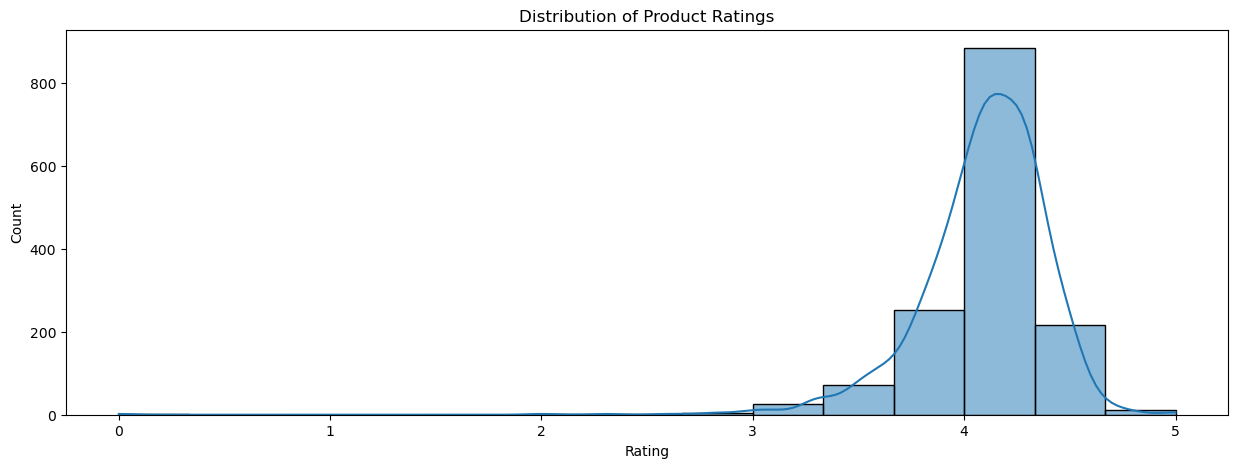

In [36]:
# Helps identify whether most products are highly rated or customers are dissatisfied.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
sns.histplot(df["rating"], bins=15, kde=True)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

#### 2. Most Common Product Categories

In [39]:
# Shows which types of products dominate the dataset.
df["category"].value_counts().head(10)

category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables                        233
Electronics|WearableTechnology|SmartWatches                                                               76
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones                                      68
Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions                                             63
Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear                                              52
Electronics|HomeTheater,TV&Video|Accessories|RemoteControls                                               49
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|MixerGrinders                                  27
Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables                                            24
Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cleaning&Ironing|Irons,Steamers&Accessories|Irons|DryIrons     24
Computers&

#### 3. Average Discount by Category 

In [41]:
# This tells us which categories offer the highest discounts.
df.groupby("category")["discount_percentage"].mean().sort_values(ascending=False).head(10)

category
Electronics|Mobiles&Accessories|MobileAccessories|Décor|PhoneCharms                                              90.0
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|CableConnectionProtectors                       90.0
Electronics|Headphones,Earbuds&Accessories|Earpads                                                               90.0
Electronics|Headphones,Earbuds&Accessories|Adapters                                                              88.0
Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Keyboard&MiceAccessories|DustCovers    87.5
Electronics|Mobiles&Accessories|MobileAccessories|Mounts|Shower&WallMounts                                       82.0
Computers&Accessories|Components|InternalHardDrives                                                              80.0
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters                                          78.5
Electronics|Mobiles&Accessories|MobileAccessori

#### 4. Top 10 Best-Rated Products

In [42]:
# Helps us identify top-performing products based on customer reviews.
df.nlargest(10, "rating")[["product_name", "rating", "rating_count"]]

,product_name,rating,rating_count
174,Syncwire LTG to USB Cable for Fast Charging Co...,5.0,5
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",5.0,0
775,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,5.0,23
1145,Swiffer Instant Electric Water Heater Faucet T...,4.8,53803
1201,"Oratech Coffee Frother electric, milk frother ...",4.8,28
1299,"Instant Pot Air Fryer, Vortex 2QT, Touch Contr...",4.8,3964
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,4.7,5935
459,Spigen EZ Fit Tempered Glass Screen Protector ...,4.7,7779
1223,"FIGMENT Handheld Milk Frother Rechargeable, 3-...",4.7,1729
1226,Zuvexa USB Rechargeable Electric Foam Maker - ...,4.7,54


#### 5. Relationship Between Discounts and Ratings

In [43]:
df[["discount_percentage", "rating"]].corr()

,discount_percentage,rating
discount_percentage,1.000000,-0.132556
rating,-0.132556,1.000000


##### The correlation is weak, so discount percentage does not strongly influence product ratings.

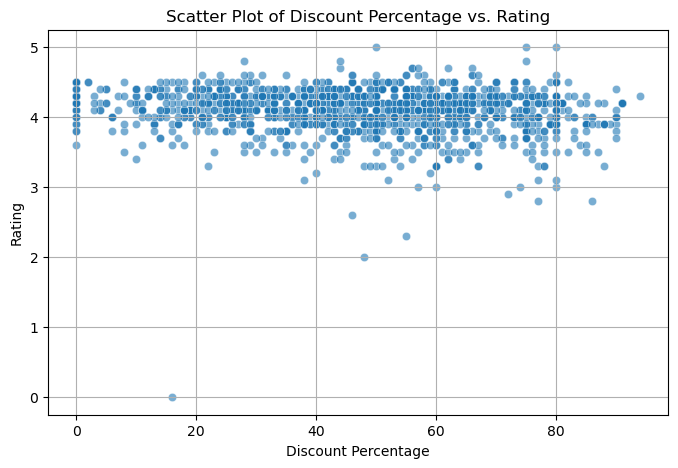

In [44]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["discount_percentage"], y=df["rating"], alpha=0.6)

plt.title("Scatter Plot of Discount Percentage vs. Rating")
plt.xlabel("Discount Percentage")
plt.ylabel("Rating")
plt.grid(True)
plt.show()

#### 6. Finding the Most Engaged Users

In [49]:
df[["user_id", "category"]].value_counts().head(10)

user_id                                                                                                                                                                                                                                  category                                                                         
AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPYWP2OUPEYNPQ,AEBWA5I4QFCA3P3OBEPMELBGN4GQ,AHMGAC6QM62UXNEOCZIHLHSXPP2Q,AFHROSCGIXUPV3FYQ7H5QOD46Q7Q,AEAMIR3CMSA32IDEINSJKHRNANTA,AF355FTXYAKFH5NYPRTE7SL3WO3Q,AG5DWPD54QGSLWJ6QUFERLPNAX4Q  Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables    10
AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBBSNLYT3ONILA,AHCTC6ULH4XB6YHDY6PCH2R772LQ,AGYHHIERNXKA6P5T7CZLXKVPT7IQ,AG4OGOFWXJZTQ2HKYIOCOY3KXF2Q,AENGU523SXMOS7JPDTW52PNNVWGQ,AEQJHCVTNINBS4FKTBGQRQTGTE5Q,AFC3FFC5PKFF5PMA52S3VCHOZ5FQ  Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables     8
AGAELRYPMTG5SADZPDYB343EASAA,AGFN4JODOM2NTF

#### 7. Identifying Categories with the Highest Price Drops

In [46]:
df.groupby("category")["price_difference"].mean().sort_values(ascending=False).head(10)


category
Home&Kitchen|Heating,Cooling&AirQuality|AirConditioners|Split-SystemAirConditioners                     33000.000000
Computers&Accessories|Laptops|TraditionalLaptops                                                        22643.000000
Computers&Accessories|ExternalDevices&DataStorage|ExternalSolidStateDrives                              21611.000000
Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cleaning&Ironing|Vacuums&FloorCare|Vacuums|RoboticVacuums    21500.000000
Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions                                           15292.650794
Home&Kitchen|Heating,Cooling&AirQuality|AirPurifiers|HEPAAirPurifiers                                   15196.250000
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|Juicers|ColdPressJuicers                     11390.000000
Computers&Accessories|Tablets                                                                           11000.000000
Home&Kitchen|Kitchen&HomeAppliances|WaterPurifiers&Acce

#### 8. Finding the Best Value Products

In [47]:
best_value_products = df[
    (df["discount_percentage"] > 30) & 
    (df["rating"] >= 4) & 
    (df["rating_count"] > 50)
]

best_value_products[["product_name", "discount_percentage", "rating", "rating_count"]].head(10)


,product_name,discount_percentage,rating,rating_count
0,Wayona Nylon Braided USB to Lightning Fast Cha...,64.0,4.2,24269
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,43.0,4.0,43994
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,53.0,4.2,94363
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,61.0,4.2,16905
6,"boAt Micro USB 55 Tangle-free, Sturdy Micro US...",65.0,4.1,15188
8,"TP-Link USB WiFi Adapter for PC(TL-WN725N), N1...",50.0,4.2,179691
9,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,33.0,4.0,43994
10,Portronics Konnect L POR-1081 Fast Charging 3A...,55.0,4.3,13391
11,boAt Rugged v3 Extra Tough Unbreakable Braided...,63.0,4.2,94363
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,69.0,4.4,426973


#### 9. Customer Segmentation by Price

In [48]:
def categorize_price(price):
    if price < 500:
        return "Budget"
    elif price < 2000:
        return "Mid-Range"
    else:
        return "Premium"

df["price_category"] = df["discounted_price"].apply(categorize_price)
df["price_category"].value_counts()

price_category
Budget       576
Mid-Range    527
Premium      362
Name: count, dtype: int64

In [51]:
df[["user_id", "category", "price_category"]].value_counts().head(10)

user_id                                                                                                                                                                                                                                  category                                                                           price_category
AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPYWP2OUPEYNPQ,AEBWA5I4QFCA3P3OBEPMELBGN4GQ,AHMGAC6QM62UXNEOCZIHLHSXPP2Q,AFHROSCGIXUPV3FYQ7H5QOD46Q7Q,AEAMIR3CMSA32IDEINSJKHRNANTA,AF355FTXYAKFH5NYPRTE7SL3WO3Q,AG5DWPD54QGSLWJ6QUFERLPNAX4Q  Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables  Budget            10
AGAELRYPMTG5SADZPDYB343EASAA,AGFN4JODOM2NTFCJQOHDBQLVDJTQ,AG7EZVSAXIVGMNDLSA55K7URQCJA,AGGF75HIEMB67OU7J3RDALBSUKQQ,AHY5CI4SU6JBYPIZ5RLAGO6W3F4A,AE4KODNBVTDCZWZO4HZM4GTRERPA,AH6HFHSYOY2OHMODD7244DHG7FUQ,AHRW5JERWYAJCZO65PDKZSOEPR6Q  Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones               Premium         

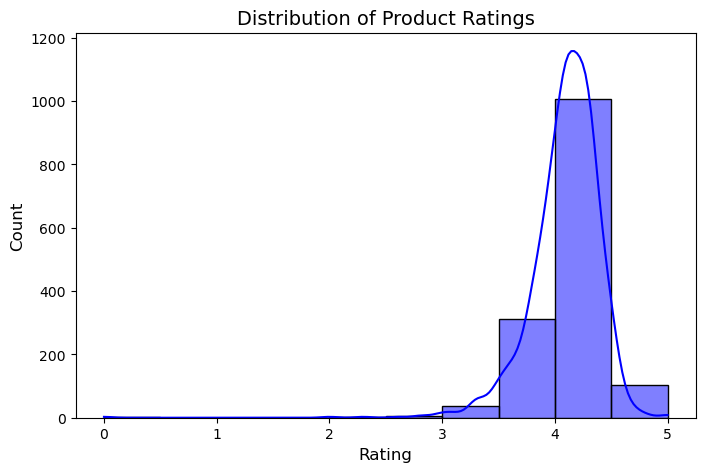

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(df["rating"], bins=10, kde=True, color='blue')

# Titles & Labels
plt.title("Distribution of Product Ratings", fontsize=14)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

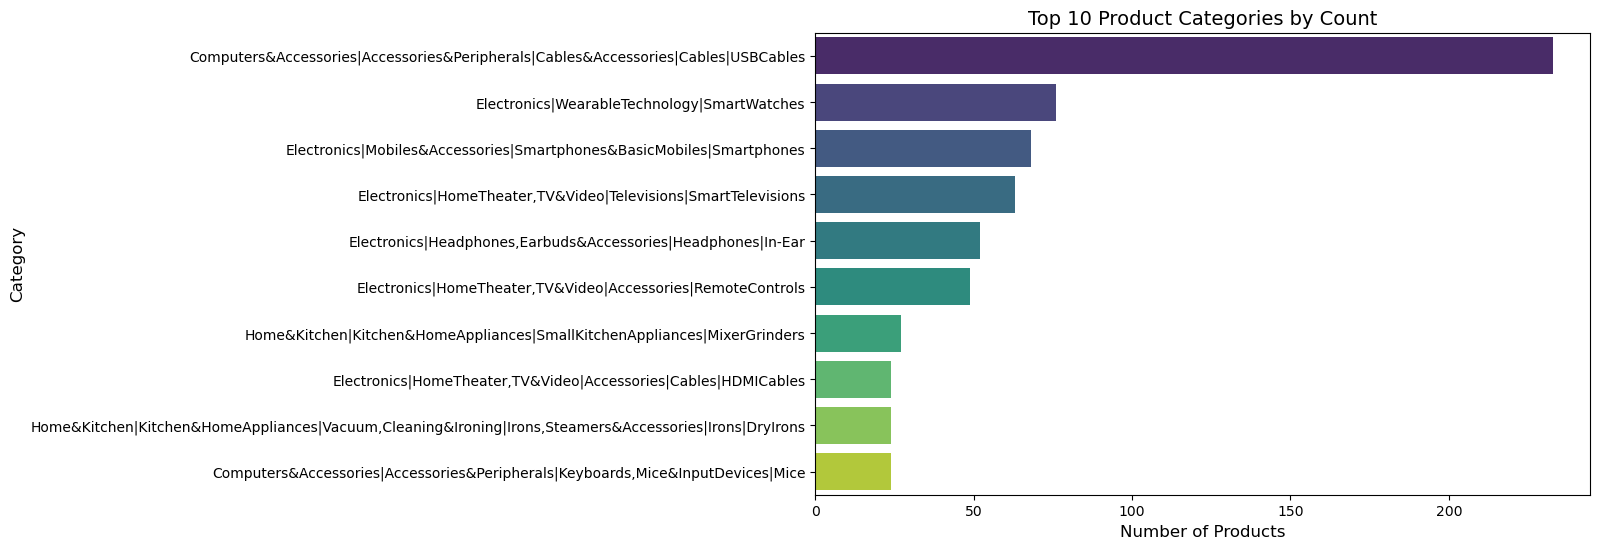

In [55]:

# Assuming 'df' is your DataFrame and 'category' is the column of interest
top_categories = df["category"].value_counts().head(10)

# Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis", hue=top_categories.index, legend=False)

# Titles & Labels
plt.title("Top 10 Product Categories by Count", fontsize=14)
plt.xlabel("Number of Products", fontsize=12)
plt.ylabel("Category", fontsize=12)

plt.show()


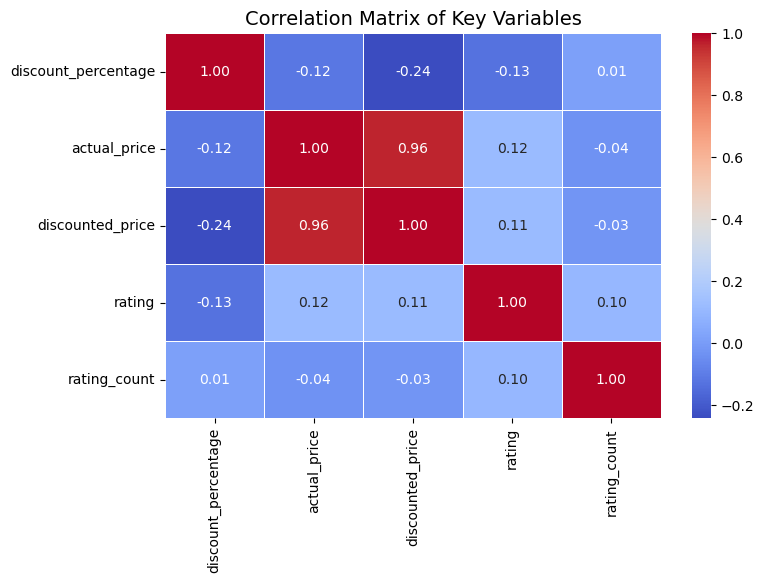

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation analysis
numeric_columns = ["discount_percentage", "actual_price", "discounted_price", "rating", "rating_count"]
correlation_matrix = df[numeric_columns].corr()

# Heatmap for visualization
plt.figure(figsize=(8,5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Title
plt.title("Correlation Matrix of Key Variables", fontsize=14)
plt.show()


In [60]:
# Calculate average discount and average rating per category
category_value = df.groupby("category").agg({"discount_percentage": "mean", "rating": "mean"}).sort_values(by="discount_percentage", ascending=False)

# Show top 10 categories
category_value.head(10)


,discount_percentage,rating
category,,
Electronics|Mobiles&Accessories|MobileAccessories|Décor|PhoneCharms,90.0,4.400000
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|CableConnectionProtectors,90.0,4.033333
"Electronics|Headphones,Earbuds&Accessories|Earpads",90.0,3.800000
"Electronics|Headphones,Earbuds&Accessories|Adapters",88.0,3.900000
"Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Keyboard&MiceAccessories|DustCovers",87.5,3.400000
Electronics|Mobiles&Accessories|MobileAccessories|Mounts|Shower&WallMounts,82.0,4.100000
Computers&Accessories|Components|InternalHardDrives,80.0,4.200000
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters,78.5,4.150000
Electronics|Mobiles&Accessories|MobileAccessories|Stands,76.4,4.160000


/var/folders/_c/znqqkj3j43g63vh_wc5my2w00000gn/T/ipykernel_29224/2053115993.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_discount = df.groupby("price_range")["discount_percentage"].mean()
/var/folders/_c/znqqkj3j43g63vh_wc5my2w00000gn/T/ipykernel_29224/2053115993.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_discount.index, y=price_discount.values, palette="magma")


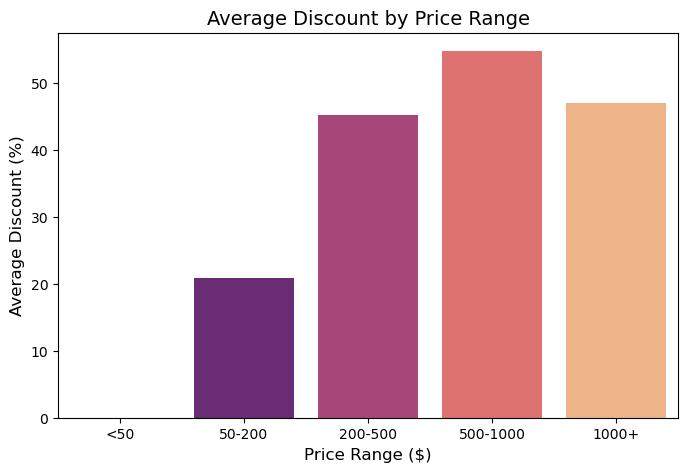

In [63]:
import numpy as np

# Define price ranges
df["price_range"] = pd.cut(df["actual_price"], bins=[0, 50, 200, 500, 1000, np.inf], labels=["<50", "50-200", "200-500", "500-1000", "1000+"])

# Average discount per price range
price_discount = df.groupby("price_range")["discount_percentage"].mean()

# Bar Plot
plt.figure(figsize=(8,5))
sns.barplot(x=price_discount.index, y=price_discount.values, palette="magma")

plt.title("Average Discount by Price Range", fontsize=14)
plt.xlabel("Price Range ($)", fontsize=12)
plt.ylabel("Average Discount (%)", fontsize=12)

plt.show()


In [65]:
# Identify which categories a user purchases from the most
user_category_pref = df.groupby(["user_id", "category"])["review_id"].count().reset_index()
top_categories = user_category_pref.sort_values(by=["user_id", "review_id"], ascending=[True, False])

# Show top 5 preferred categories per user
top_categories.groupby("user_id").head(5)


,user_id,category,review_id
0,"AE22Y3KIS7SE6LI3HE2VS6WWPU4Q,AHWEYO2IJ5I5GDWZA...","Electronics|HomeTheater,TV&Video|Accessories|R...",1
1,"AE23RS3W7GZO7LHYKJU6KSKVM4MQ,AEQUNEY6GQOTEGUMS...",Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,1
2,AE242TR3GQ6TYC6W4SJ5UYYKBTYQ,"Electronics|HomeTheater,TV&Video|Accessories|R...",1
3,"AE27UOZENYSWCQVQRRUQIV2ZM7VA,AGMYSLV6NNOAYES25...",Electronics|Mobiles&Accessories|Smartphones&Ba...,4
4,"AE2JTMRKTUOIVIZWS2WDGTMNTU4Q,AF4QXCB32VC2DVE7O...",Computers&Accessories|Accessories&Peripherals|...,2
...,...,...,...
1191,"AHZFKWGDBRQKNMNQ4ZPL52OZBRKA,AGBEFVJFOQIRF7C7K...",Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,1
1192,"AHZJHJWFZLYD64GVP4PXVI2F4LXA,AEUCRZPOISXKHXMCZ...",Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,1
1193,"AHZNSNBVKQR4OGJAQHE4DCDA4YHA,AFBW6COTZXGHQMWVD...",Electronics|WearableTechnology|SmartWatches,2
1194,"AHZWJCVEIEI76H2VGMUSN5D735IQ,AH2DFUHFTG4CKQFVG...",Computers&Accessories|Accessories&Peripherals|...,3
